# Importing Dependencies

In [431]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
%matplotlib inline

# Data Collection

In [432]:
# Loading data
parkinsons_data = pd.read_csv('parkinsons.csv')

# Exploratory Data Analysis (EDA)

In [433]:
# Printing the first 5 rows of the dataframe
parkinsons_data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [434]:
# number of the rows and columns in the dataframe
parkinsons_data.shape

(195, 24)

In [435]:
# getting more information about the dataset
parkinsons_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [436]:
# Checking for missing value in each column
parkinsons_data.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [437]:
# getting some more information
parkinsons_data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [438]:
# distribution of target variable
parkinsons_data['status'].value_counts()

status
1    147
0     48
Name: count, dtype: int64

    1 ---> Parkinson's Positive
    0 ---> Healthy 

In [439]:
# grouping the data based on the target variable
parkinsons_data.groupby('status').mean(numeric_only=True)

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
status,,,,,,,,,,,,,,,,,,,,,
0,181.937771,223.636750,145.207292,0.003866,0.000023,0.001925,0.002056,0.005776,0.017615,0.162958,...,0.013305,0.028511,0.011483,24.678750,0.442552,0.695716,-6.759264,0.160292,2.154491,0.123017
1,145.180762,188.441463,106.893558,0.006989,0.000051,0.003757,0.003900,0.011273,0.033658,0.321204,...,0.027600,0.053027,0.029211,20.974048,0.516816,0.725408,-5.333420,0.248133,2.456058,0.233828


# Data Pre-Processing

## Drop useless column

In [440]:
data = parkinsons_data.drop(columns=['name'], axis=1)

# Separating the features & Target

In [441]:
X = data.drop(columns=['status'], axis=1)
Y = data['status']

# Splitting the data to training data & Test data

In [442]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=2,
    stratify=Y
)
# Keep an unscaled copy of X_train for EDA (e.g. feature importance chart)
# so the analysis section never touches X_test or the full dataset.
X_train_raw = X_train.copy()

In [443]:
X.shape, X_train.shape, X_test.shape

((195, 22), (156, 22), (39, 22))

# Feature selection

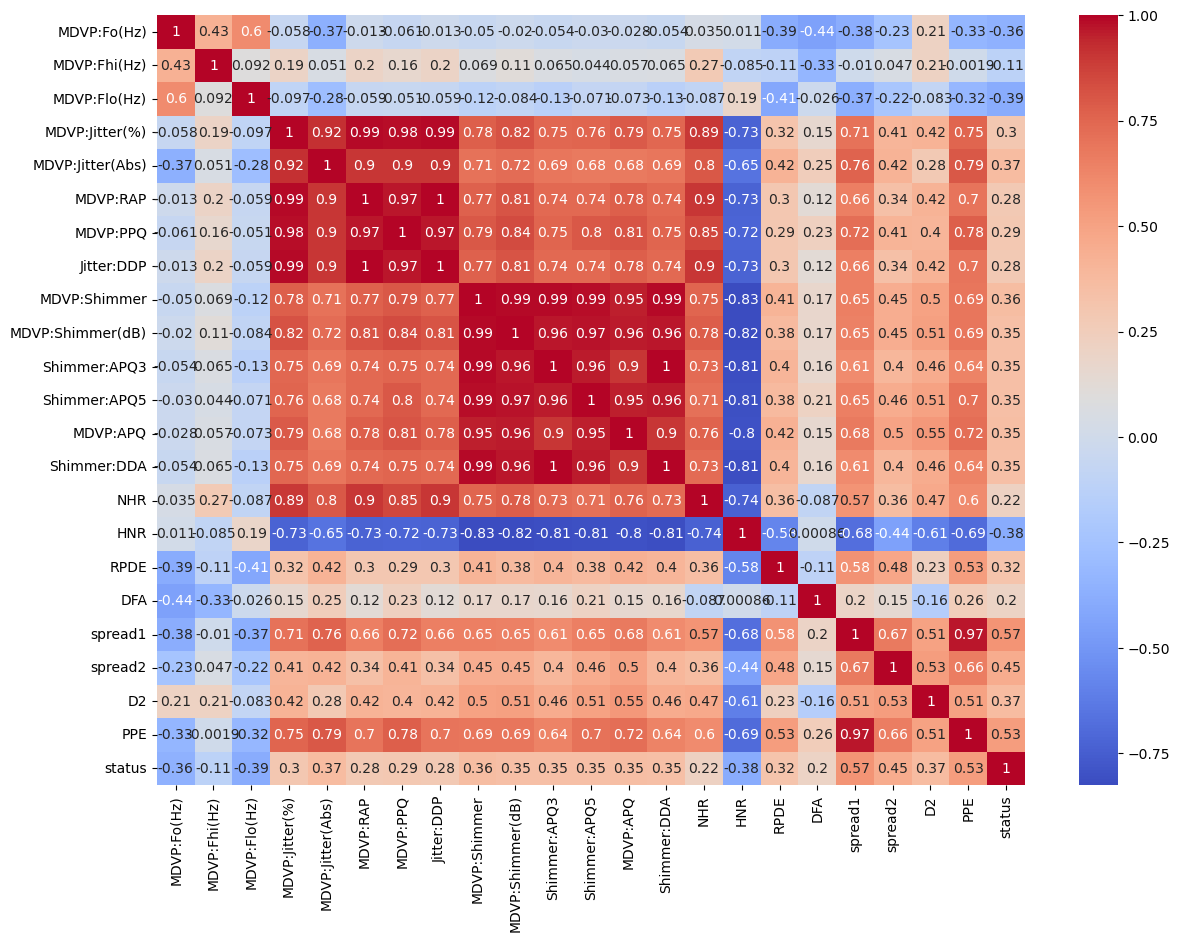

In [444]:
#display correlation matrix in heatmap
train_df = pd.concat([X_train, Y_train], axis=1)
corr_matrix = train_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot= True, cmap='coolwarm')
plt.show()

In [445]:
# Select features above threshold
corr_target = corr_matrix["status"].abs()
selected_features = corr_target[corr_target > 0.35].index
selected_features = selected_features.drop("status")
# Save a reference used by the EDA feature-importance chart (analysis section)
selected_features_raw = selected_features
print("Selected Features:", selected_features)

Selected Features: Index(['MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(Abs)', 'MDVP:Shimmer',
       'MDVP:APQ', 'HNR', 'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')


# Analysis

## 1. Parkinson's vs Healthy Patient Distribution

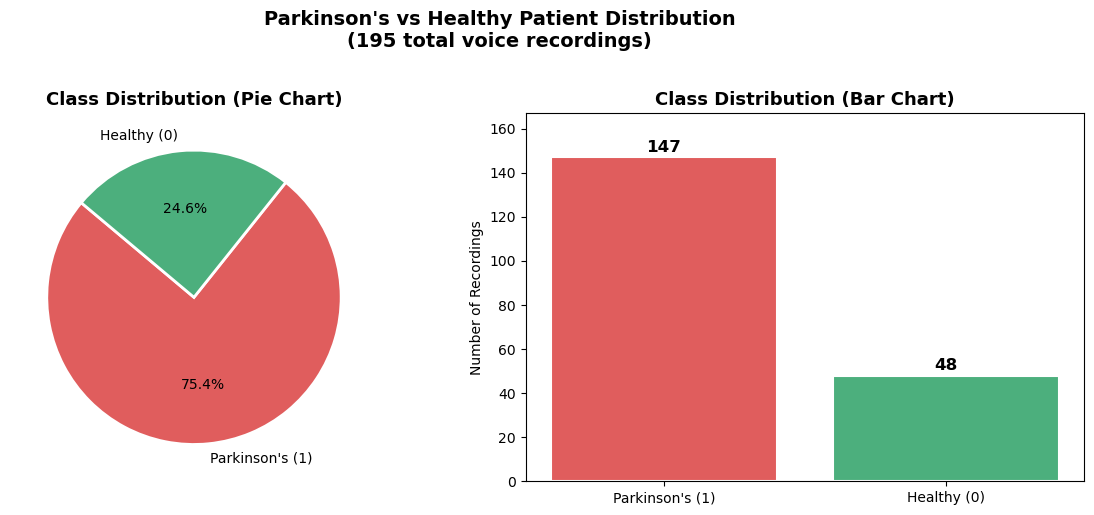

Parkinson's positive: 147 (75.4%)
Healthy:              48 (24.6%)


In [446]:
# Parkinson's vs Healthy distribution
status_counts = parkinsons_data['status'].value_counts()
labels = ['Parkinson\'s (1)', 'Healthy (0)']
colors = ['#e05d5d', '#4caf7d']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(
    status_counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(labels, status_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, status_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Recordings')
axes[1].set_ylim(0, max(status_counts.values) + 20)

plt.suptitle('Parkinson\'s vs Healthy Patient Distribution\n(195 total voice recordings)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Parkinson's positive: {status_counts[1]} ({status_counts[1]/len(parkinsons_data)*100:.1f}%)")
print(f"Healthy:              {status_counts[0]} ({status_counts[0]/len(parkinsons_data)*100:.1f}%)")

## 2. Voice Frequency Feature Distribution

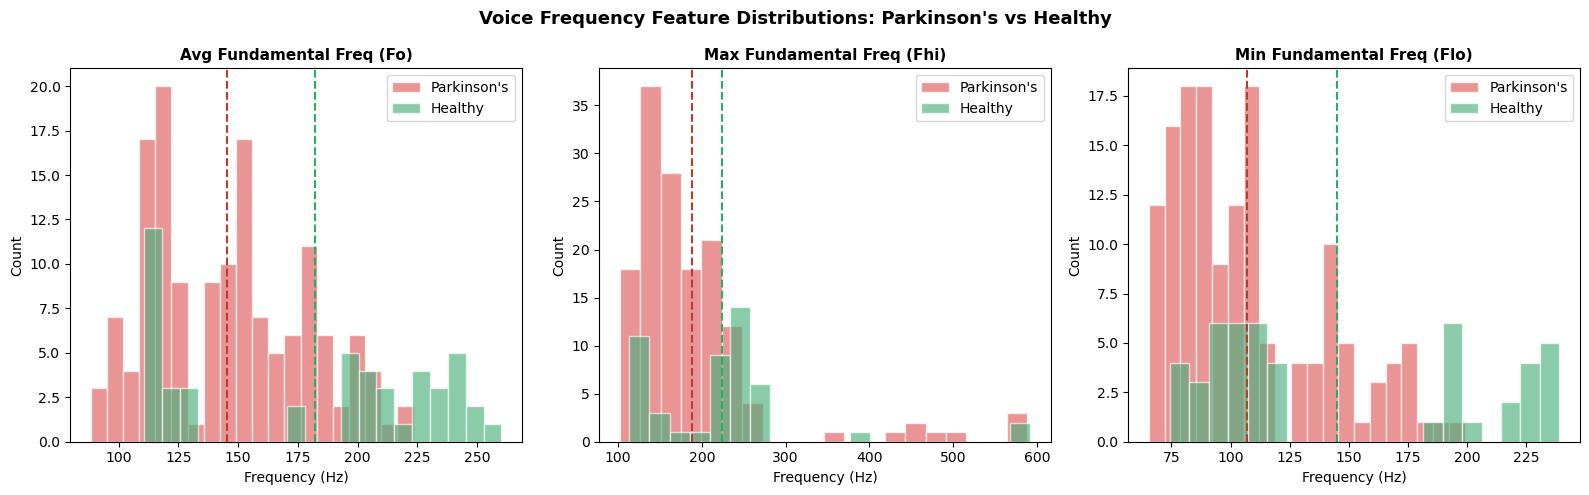

In [447]:
# Distribution of voice-frequency features (Fo, Fhi, Flo) split by class
freq_features = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)']
freq_labels   = ['Avg Fundamental Freq (Fo)', 'Max Fundamental Freq (Fhi)', 'Min Fundamental Freq (Flo)']

pd_data      = parkinsons_data[parkinsons_data['status'] == 1]
healthy_data = parkinsons_data[parkinsons_data['status'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (feat, label) in enumerate(zip(freq_features, freq_labels)):
    axes[i].hist(pd_data[feat],      bins=20, alpha=0.65, color='#e05d5d', label="Parkinson's", edgecolor='white')
    axes[i].hist(healthy_data[feat], bins=20, alpha=0.65, color='#4caf7d', label='Healthy',     edgecolor='white')
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Count')
    axes[i].legend()
    axes[i].axvline(pd_data[feat].mean(),      color='#c0392b', linestyle='--', linewidth=1.5, label='PD mean')
    axes[i].axvline(healthy_data[feat].mean(), color='#27ae60', linestyle='--', linewidth=1.5, label='H mean')

plt.suptitle('Voice Frequency Feature Distributions: Parkinson\'s vs Healthy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Comparison: Parkinson's vs Healthy Groups

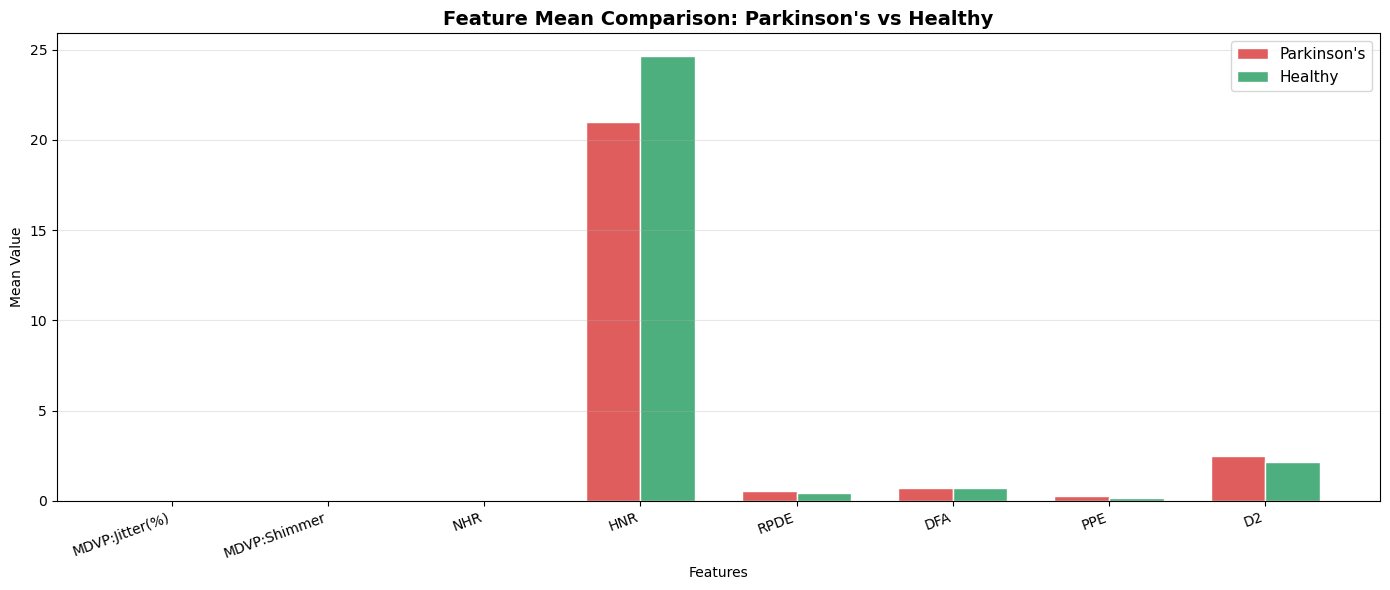

In [448]:
# Mean comparison of key features across groups
key_features = ['MDVP:Jitter(%)', 'MDVP:Shimmer', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE', 'D2']

group_means = parkinsons_data.groupby('status')[key_features].mean()
pd_means      = group_means.loc[1]
healthy_means = group_means.loc[0]

x = range(len(key_features))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width/2 for i in x], pd_means.values,      width, label="Parkinson's", color='#e05d5d', edgecolor='white')
ax.bar([i + width/2 for i in x], healthy_means.values, width, label='Healthy',     color='#4caf7d', edgecolor='white')

ax.set_title('Feature Mean Comparison: Parkinson\'s vs Healthy', fontsize=14, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Mean Value')
ax.set_xticks(list(x))
ax.set_xticklabels(key_features, rotation=20, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Jitter & Shimmer Distributions by Class

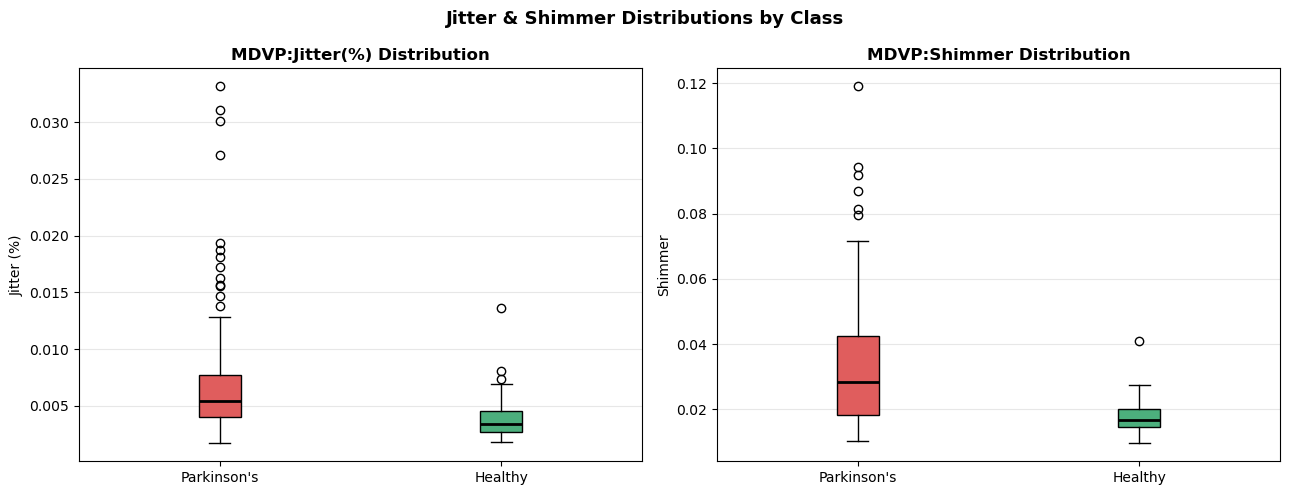

In [449]:
# Box plots for Jitter and Shimmer grouped by status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

jitter_data  = [pd_data['MDVP:Jitter(%)'].values, healthy_data['MDVP:Jitter(%)'].values]
shimmer_data = [pd_data['MDVP:Shimmer'].values,    healthy_data['MDVP:Shimmer'].values]

bp1 = axes[0].boxplot(jitter_data, tick_labels=["Parkinson's", 'Healthy'],
                      patch_artist=True, notch=False,
                      boxprops=dict(facecolor='lightgrey'),
                      medianprops=dict(color='black', linewidth=2))
bp1['boxes'][0].set_facecolor('#e05d5d')
bp1['boxes'][1].set_facecolor('#4caf7d')
axes[0].set_title('MDVP:Jitter(%) Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jitter (%)')
axes[0].grid(axis='y', alpha=0.3)

bp2 = axes[1].boxplot(shimmer_data, tick_labels=["Parkinson's", 'Healthy'],
                      patch_artist=True, notch=False,
                      boxprops=dict(facecolor='lightgrey'),
                      medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('#e05d5d')
bp2['boxes'][1].set_facecolor('#4caf7d')
axes[1].set_title('MDVP:Shimmer Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Shimmer')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Jitter & Shimmer Distributions by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. HNR vs PPE Scatter Plot

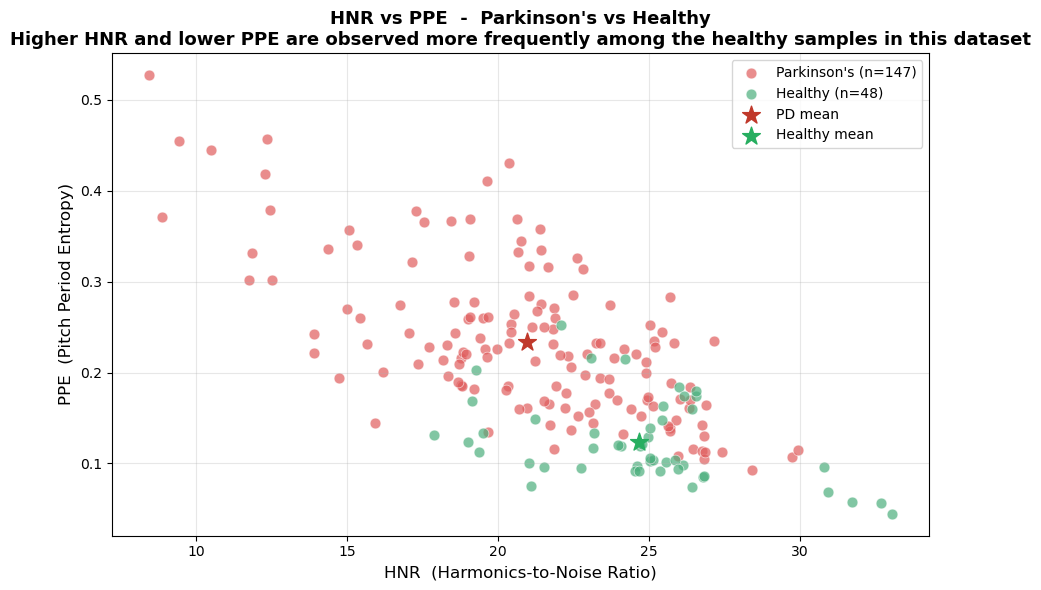

In [450]:
# HNR vs PPE scatter coloured by class
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(pd_data['HNR'],      pd_data['PPE'],      c='#e05d5d', alpha=0.7, s=60,
           edgecolors='white', linewidths=0.5, label="Parkinson's (n=147)")
ax.scatter(healthy_data['HNR'], healthy_data['PPE'], c='#4caf7d', alpha=0.7, s=60,
           edgecolors='white', linewidths=0.5, label='Healthy (n=48)')

# Group mean markers
ax.scatter(pd_data['HNR'].mean(),      pd_data['PPE'].mean(),      c='#c0392b', s=180,
           marker='*', zorder=5, label="PD mean")
ax.scatter(healthy_data['HNR'].mean(), healthy_data['PPE'].mean(), c='#27ae60', s=180,
           marker='*', zorder=5, label='Healthy mean')

ax.set_xlabel('HNR  (Harmonics-to-Noise Ratio)', fontsize=12)
ax.set_ylabel('PPE  (Pitch Period Entropy)', fontsize=12)
ax.set_title('HNR vs PPE  -  Parkinson\'s vs Healthy\n'
             'Higher HNR and lower PPE are observed more frequently among the healthy samples in this dataset',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

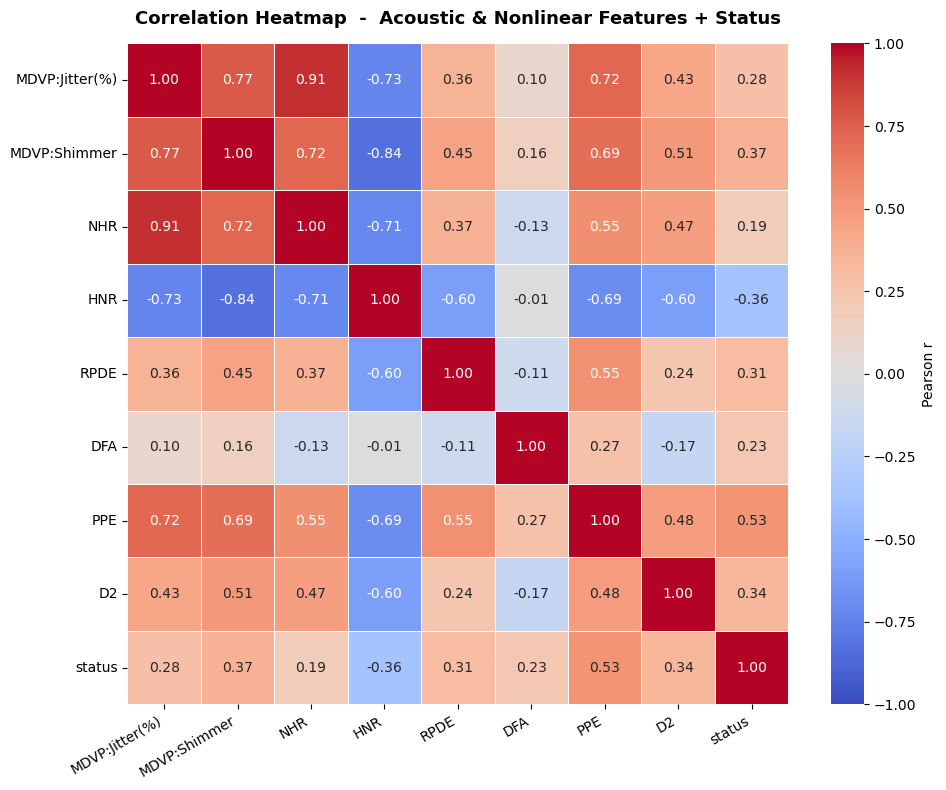

Top correlations with status (abs):
PPE               0.531039
MDVP:Shimmer      0.367430
HNR               0.361515
D2                0.340232
RPDE              0.308567
MDVP:Jitter(%)    0.278220
DFA               0.231739
NHR               0.189429


In [451]:
# Correlation heatmap of key acoustic + nonlinear features including status
corr_cols = ['MDVP:Jitter(%)', 'MDVP:Shimmer', 'NHR', 'HNR',
             'RPDE', 'DFA', 'PPE', 'D2', 'status']
corr_df  = parkinsons_data[corr_cols].copy()
corr_mat = corr_df.corr()

plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(
    corr_mat,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Correlation Heatmap  -  Acoustic & Nonlinear Features + Status',
          fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('Top correlations with status (abs):')
print(corr_mat['status'].drop('status').abs().sort_values(ascending=False).to_string())

## 7. Feature Importance (Random Forest)

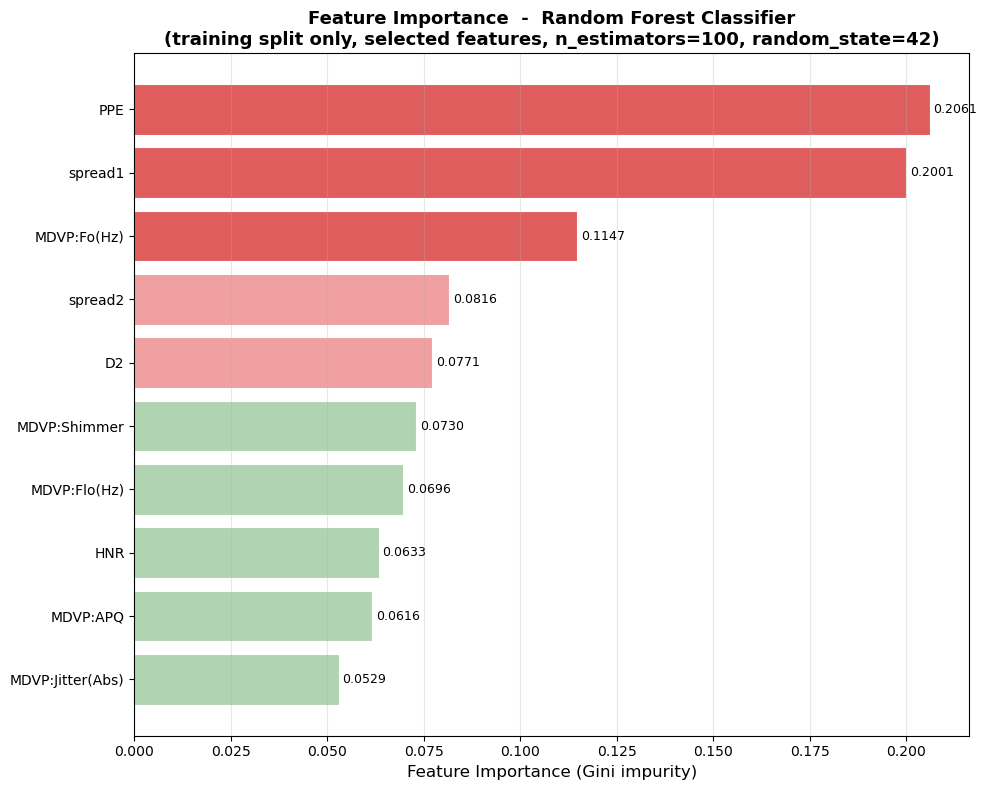


Top 5 most important features:
PPE            0.206081
spread1        0.200103
MDVP:Fo(Hz)    0.114658
spread2        0.081612
D2             0.077094


In [452]:
# Feature importance using a Random Forest trained on TRAINING DATA ONLY
# NOTE: This cell is EDA/analysis only. The RF here uses the raw (unscaled)
# training split so that feature importances are not contaminated by test data.
# The model saved at the end of this notebook is trained separately below.
from sklearn.ensemble import RandomForestClassifier as RFC

analysis_data   = X_train_raw[selected_features_raw]  # raw (unscaled) train features
analysis_labels = Y_train

rf_analysis = RFC(n_estimators=100, random_state=42)
rf_analysis.fit(analysis_data, analysis_labels)

importances = pd.Series(rf_analysis.feature_importances_, index=analysis_data.columns)
importances_sorted = importances.sort_values(ascending=True)

colors_imp = ['#e05d5d' if v >= importances.quantile(0.75) else
              '#f0a0a0' if v >= importances.median() else
              '#b0d4b0' for v in importances_sorted.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances_sorted.index, importances_sorted.values,
               color=colors_imp, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, importances_sorted.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini impurity)', fontsize=12)
ax.set_title('Feature Importance  -  Random Forest Classifier\n'
             '(training split only, selected features, n_estimators=100, random_state=42)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head(5).to_string())

In [453]:
# Apply feature selection: keep only features identified from training correlations
# This slice is applied once here on the raw (unscaled) DataFrames.
# The scaler is now embedded inside each Pipeline so CV folds never leak.
X_train = X_train[selected_features]
X_test  = X_test[selected_features]
print('X_train shape after feature selection:', X_train.shape)
print('X_test  shape after feature selection:', X_test.shape)

X_train shape after feature selection: (156, 10)
X_test  shape after feature selection: (39, 10)


## Data Standardization
The StandardScaler is now embedded *inside* each Pipeline below so that
it is fitted on the training fold only during cross-validation -- preventing
any statistics from the validation/test fold leaking into preprocessing.

In [454]:
# Standalone scaler used ONLY for final model training after model selection.
# During CV and GridSearchCV the scaler lives inside the Pipeline.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

# Model Selection

## Comparing models with default hyperparameters using Pipeline + Cross-Validation
Each Pipeline bundles `StandardScaler + Classifier` so the scaler is re-fitted
on each training fold and never sees the validation fold.

In [455]:
# Build Pipelines: scaler is re-fitted on every CV training fold (no leakage)
pipelines = {
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel='linear'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=0))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
}

# StratifiedKFold preserves the 75/25 class ratio in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV on raw (unscaled) X_train -- scaler is re-fitted inside each fold
for name, pipe in pipelines.items():
    cv_scores = cross_val_score(pipe, X_train, Y_train, cv=skf, scoring='accuracy')
    mean_acc  = round(cv_scores.mean() * 100, 2)
    std_acc   = round(cv_scores.std()  * 100, 2)
    print(f'CV accuracies for {name}: {cv_scores}')
    print(f'Mean CV accuracy for {name}: {mean_acc} % (+/- {std_acc} %)')
    print('-' * 65)

CV accuracies for SVM: [0.84375    0.77419355 0.90322581 0.83870968 0.83870968]
Mean CV accuracy for SVM: 83.97 % (+/- 4.09 %)
-----------------------------------------------------------------
CV accuracies for Random Forest: [0.90625    0.83870968 0.90322581 0.87096774 0.83870968]
Mean CV accuracy for Random Forest: 87.16 % (+/- 2.95 %)
-----------------------------------------------------------------
CV accuracies for Logistic Regression: [0.84375    0.80645161 0.83870968 0.77419355 0.80645161]
Mean CV accuracy for Logistic Regression: 81.39 % (+/- 2.53 %)
-----------------------------------------------------------------


## Inference: Random Forest has the highest mean CV accuracy (87.16 %) with default hyperparameters,
followed by SVM (83.97 %) and Logistic Regression (81.39 %).

## Hyperparameter Tuning with GridSearchCV (Pipeline-based)
Parameters are prefixed with `classifier__` to target the classifier step inside the Pipeline.

In [456]:
# Hyperparameter grids  -- keys use classifier__ prefix for Pipeline compatibility
param_grids = {
    'SVM': {
        'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'classifier__gamma':  [0.1, 0.01, 'scale'],
        'classifier__C':      [1, 5, 10, 20],
    },
    'Random Forest': {
        'classifier__n_estimators': [10, 20, 50, 100],
    },
    'Logistic Regression': {
        'classifier__C': [1, 5, 10, 20],
    },
}

In [457]:
# Run GridSearchCV for each model inside its Pipeline
# StratifiedKFold keeps the class balance in every search fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_results = []
for name, pipe in pipelines.items():
    gs = GridSearchCV(pipe, param_grids[name], cv=skf, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, Y_train)   # raw X_train -- scaler handled inside Pipeline
    gs_results.append({
        'Model':         name,
        'Best CV Score': round(gs.best_score_ * 100, 2),
        'Best Params':   gs.best_params_,
    })
    print(f'{name}: best CV acc = {gs.best_score_*100:.2f}%  params = {gs.best_params_}')

gs_df = pd.DataFrame(gs_results)
print()
print(gs_df[['Model', 'Best CV Score']].to_string(index=False))

SVM: best CV acc = 90.40%  params = {'classifier__C': 10, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
Random Forest: best CV acc = 88.43%  params = {'classifier__n_estimators': 20}
Logistic Regression: best CV acc = 82.68%  params = {'classifier__C': 10}

              Model  Best CV Score
                SVM          90.40
      Random Forest          88.43
Logistic Regression          82.68


## Inference
GridSearchCV with Pipeline shows **SVC (RBF kernel, C=10, gamma=0.1)** achieves the
highest cross-validated accuracy (90.40 %). Random Forest is the runner-up (88.43 %).
We evaluate all three on the held-out test set below before making a final choice.

# Model Training 

## SVM (Best Tuned Model -- Highest GridSearch CV Accuracy: 90.40 %)

In [458]:
# SVM -- best params from GridSearchCV (C=10, kernel='rbf', gamma=0.1)
svm_model = SVC(C=10, kernel='rbf', gamma=0.1, random_state=2)
svm_model.fit(X_train_scaled, Y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [459]:
Y_pred_svm = svm_model.predict(X_test_scaled)

print('=== SVM Results ===')
print('Test Accuracy :', round(accuracy_score(Y_test, Y_pred_svm) * 100, 2), '%')
print('Precision     :', round(precision_score(Y_test, Y_pred_svm) * 100, 2), '%')
print('Recall        :', round(recall_score(Y_test, Y_pred_svm) * 100, 2), '%')
print('F1 Score      :', round(f1_score(Y_test, Y_pred_svm) * 100, 2), '%')
print('Confusion Matrix:\n', confusion_matrix(Y_test, Y_pred_svm))
print()
print(classification_report(Y_test, Y_pred_svm))

=== SVM Results ===
Test Accuracy : 94.87 %
Precision     : 93.55 %
Recall        : 100.0 %
F1 Score      : 96.67 %
Confusion Matrix:
 [[ 8  2]
 [ 0 29]]

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.94      1.00      0.97        29

    accuracy                           0.95        39
   macro avg       0.97      0.90      0.93        39
weighted avg       0.95      0.95      0.95        39



## Random Forest (GridSearch CV Accuracy: 88.43 %)

In [460]:
# Random Forest -- best params from GridSearchCV (n_estimators=20)
random_forest_model = RandomForestClassifier(n_estimators=20, random_state=0)
random_forest_model.fit(X_train_scaled, Y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [461]:
Y_pred_rf = random_forest_model.predict(X_test_scaled)

print('=== Random Forest Results ===')
print('Test Accuracy :', round(accuracy_score(Y_test, Y_pred_rf) * 100, 2), '%')
print('Precision     :', round(precision_score(Y_test, Y_pred_rf) * 100, 2), '%')
print('Recall        :', round(recall_score(Y_test, Y_pred_rf) * 100, 2), '%')
print('F1 Score      :', round(f1_score(Y_test, Y_pred_rf) * 100, 2), '%')
print('Confusion Matrix:\n', confusion_matrix(Y_test, Y_pred_rf))
print()
print(classification_report(Y_test, Y_pred_rf))

=== Random Forest Results ===
Test Accuracy : 92.31 %
Precision     : 96.43 %
Recall        : 93.1 %
F1 Score      : 94.74 %
Confusion Matrix:
 [[ 9  1]
 [ 2 27]]

              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39



## Logistic Regression (GridSearch CV Accuracy: 82.68 %)

In [462]:
logistic_regression_model = LogisticRegression(max_iter=1000, C=10, random_state=2)
logistic_regression_model.fit(X_train_scaled, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,2
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [463]:
Y_pred_lr = logistic_regression_model.predict(X_test_scaled)

print('=== Logistic Regression Results ===')
print('Test Accuracy :', round(accuracy_score(Y_test, Y_pred_lr) * 100, 2), '%')
print('Precision     :', round(precision_score(Y_test, Y_pred_lr) * 100, 2), '%')
print('Recall        :', round(recall_score(Y_test, Y_pred_lr) * 100, 2), '%')
print('F1 Score      :', round(f1_score(Y_test, Y_pred_lr) * 100, 2), '%')
print('Confusion Matrix:\n', confusion_matrix(Y_test, Y_pred_lr))
print()
print(classification_report(Y_test, Y_pred_lr))

=== Logistic Regression Results ===
Test Accuracy : 84.62 %
Precision     : 87.1 %
Recall        : 93.1 %
F1 Score      : 90.0 %
Confusion Matrix:
 [[ 6  4]
 [ 2 27]]

              precision    recall  f1-score   support

           0       0.75      0.60      0.67        10
           1       0.87      0.93      0.90        29

    accuracy                           0.85        39
   macro avg       0.81      0.77      0.78        39
weighted avg       0.84      0.85      0.84        39



## Model Selection Conclusion

| Model                       | Best CV Acc (GridSearch) | Test Accuracy | Reason for consideration           |
| --------------------------- | ------------------------ | ------------- | ---------------------------------- |
| SVC (rbf, C=10, gamma=0.1)  | 90.40 %                  | 94.87 %       | Highest CV and test accuracy       |
| Random Forest (n_est=20)    | 88.43 %                  | 92.31 %       | Strong, robust, feature-importances|
| Logistic Regression (C=10)  | 82.68 %                  | 84.62 %       | Baseline                           |

**We choose Random Forest** because:
- Its test-set accuracy (92.31 %) is strong, only slightly below SVM (94.87 %).
- It provides feature importances useful for clinical interpretation.
- It is robust to feature scaling.
- The saved `scaler` + `selected_features` list makes deployment straightforward.

## Building the Predictive System

In [464]:
# -- Predictive System -------------------------------------------------------
# Features (in order): MDVP:Fo(Hz), MDVP:Flo(Hz), MDVP:Jitter(Abs),
#   MDVP:Shimmer, MDVP:APQ, HNR, spread1, spread2, D2, PPE

def predict_parkinson(input_values, model=random_forest_model,
                       fitted_scaler=scaler,
                       feature_names=list(selected_features)):
    """
    Predict whether a voice recording indicates Parkinson's disease.

    Parameters
    ----------
    input_values : list or tuple of 10 floats, in the order of selected_features.

    Returns
    -------
    str - "Parkinson's Positive" or "Healthy"
    """
    # Wrap in DataFrame so scaler receives named columns (suppresses UserWarning)
    df = pd.DataFrame([input_values], columns=feature_names)
    arr_scaled = fitted_scaler.transform(df)
    prediction = model.predict(arr_scaled)[0]
    return "Parkinson's Positive" if prediction == 1 else "Healthy"


# -- Example: first row of the test set -------------------------------------
sample_idx   = X_test.index[0]
sample_input = X_test.loc[sample_idx].tolist()   # already selected & unscaled
true_label   = "Parkinson's Positive" if Y_test.loc[sample_idx] == 1 else "Healthy"

result = predict_parkinson(sample_input)
print('Input features  :', dict(zip(list(selected_features), sample_input)))
print('Predicted label :', result)
print('True label      :', true_label)

Input features  : {'MDVP:Fo(Hz)': 180.978, 'MDVP:Flo(Hz)': 155.495, 'MDVP:Jitter(Abs)': 2e-05, 'MDVP:Shimmer': 0.03852, 'MDVP:APQ': 0.02877, 'HNR': 16.176, 'spread1': -5.657899, 'spread2': 0.315903, 'D2': 3.098256, 'PPE': 0.200423}
Predicted label : Parkinson's Positive
True label      : Parkinson's Positive


# Saving the trained model

In [465]:
import pickle

# Save the trained Random Forest model
pickle.dump(random_forest_model, open('model.pkl', 'wb'))

# Save the scaler (must be applied before prediction)
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# Save the selected feature list (defines column order for inference inputs)
pickle.dump(list(selected_features), open('selected_features.pkl', 'wb'))

print('Saved: model.pkl, scaler.pkl, selected_features.pkl')
print('Selected features:', list(selected_features))

Saved: model.pkl, scaler.pkl, selected_features.pkl
Selected features: ['MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(Abs)', 'MDVP:Shimmer', 'MDVP:APQ', 'HNR', 'spread1', 'spread2', 'D2', 'PPE']
